
# Chapter 4: Baseline Forecasting & Model Evaluation

## Building and Validating the First Forecasting System

This notebook demonstrates how baseline forecasting systems are developed and evaluated using realistic retail sales data. The workflow follows a professional forecasting pipeline including:

- realistic time series simulation
- train-test splitting
- naive forecasting
- seasonal naive forecasting
- moving average forecasting
- forecast visualization
- model evaluation using MAE, RMSE, and MAPE

The goal is not to build the most advanced model, but to understand how forecasting systems behave under realistic business conditions.



# 1. Import Required Libraries

We begin by importing the libraries required for data manipulation, visualization, and model evaluation.


In [30]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

plt.style.use('default')



# 2. Create a Realistic Retail Sales Dataset

Instead of manually entering perfectly smooth values, we generate a more realistic retail sales environment.

The dataset contains:

- long-term business growth
- seasonal fluctuations
- random business noise
- promotional spikes and temporary drops

This structure better reflects real operational forecasting systems.


In [31]:

# Ensure reproducibility
np.random.seed(42)

# Monthly dates
date = pd.date_range(start='2023-01-01', periods=36, freq='M')

# Long-term upward trend
trend = np.linspace(120, 260, 36)

# Seasonal pattern
seasonality = 20 * np.sin(2 * np.pi * np.arange(36) / 12)

# Random fluctuations
noise = np.random.normal(0, 8, 36)

# Promotional spikes and temporary demand drops
promotion_effect = np.array([
    0,0,10,0,0,15,0,0,-5,0,20,25,
    0,0,12,0,0,18,0,0,-8,0,22,28,
    0,0,15,0,0,20,0,0,-6,0,25,30
])

# Final sales values
sales = trend + seasonality + noise + promotion_effect

# Create dataframe
df = pd.DataFrame({
    'Date': date,
    'Sales': sales.round(0)
})

df.set_index('Date', inplace=True)

df.head()


C:\Users\oadsa\AppData\Local\Temp\ipykernel_11276\891364084.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date = pd.date_range(start='2023-01-01', periods=36, freq='M')


,Sales
Date,
2023-01-31,124.0
2023-02-28,133.0
2023-03-31,161.0
2023-04-30,164.0
2023-05-31,151.0



# 3. Visualize the Time Series

The chart below shows how sales evolve over time. Notice that the series contains trend, seasonality, and irregular fluctuations simultaneously.


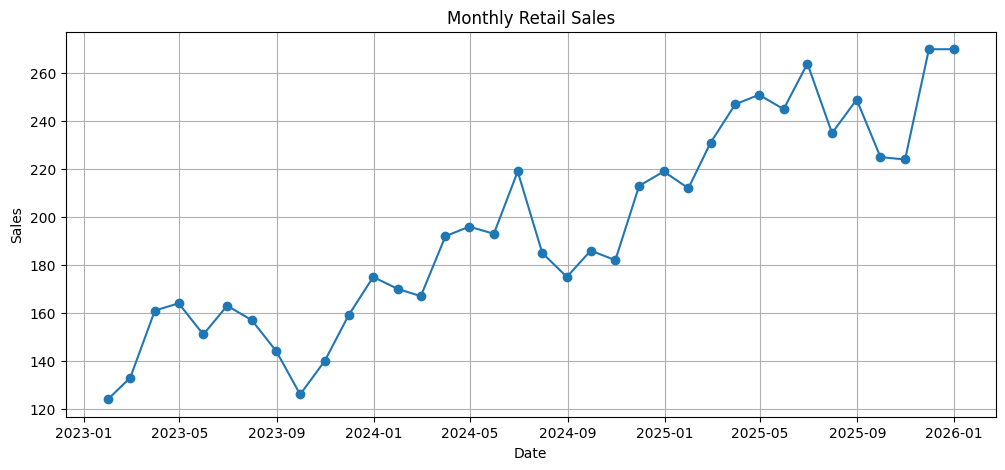

In [32]:

plt.figure(figsize=(12,5))

plt.plot(
    df.index,
    df['Sales'],
    marker='o'
)

plt.title("Monthly Retail Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)

plt.show()



# 4. Train-Test Split

In forecasting, future observations must never influence the past.

To simulate real forecasting conditions:

- the training set contains historical observations
- the test set contains unseen future observations

We use an 80/20 split.


In [33]:

# 80/20 split
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size].copy()
test = df.iloc[train_size:].copy()

print("Training observations:", len(train))
print("Test observations:", len(test))


Training observations: 28
Test observations: 8



# 5. Baseline Forecasting Models

Baseline models establish a reference level of forecasting performance.

If a sophisticated forecasting model cannot outperform these simple approaches, then the advanced model may not be learning meaningful structure from the data.



## 5.1 Naive Forecast

The naive forecast assumes that the next value will be equal to the most recent observation.


In [34]:

df['Naive_Forecast'] = df['Sales'].shift(1)
df.head()


,Sales,Naive_Forecast
Date,,
2023-01-31,124.0,NaN
2023-02-28,133.0,124.0
2023-03-31,161.0,133.0
2023-04-30,164.0,161.0
2023-05-31,151.0,164.0


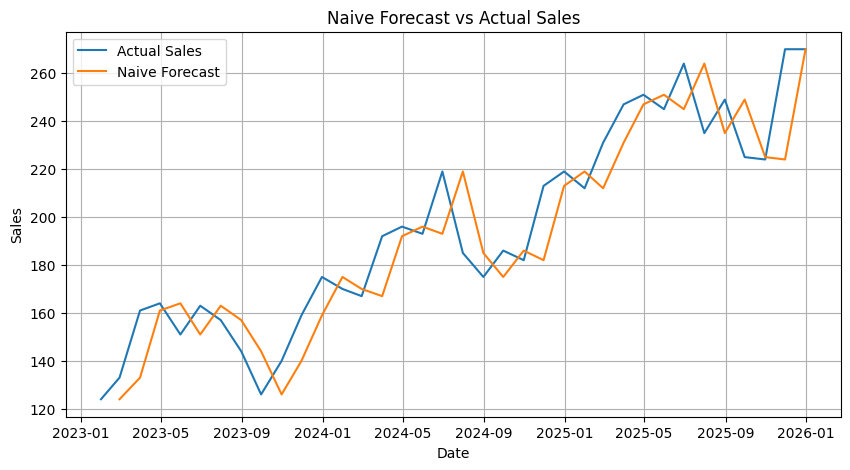

In [35]:
plt.figure(figsize=(10,5))

plt.plot(df.index, df['Sales'], label='Actual Sales')
plt.plot(df.index, df['Naive_Forecast'], label='Naive Forecast')

plt.title("Naive Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()


## 5.2 Seasonal Naive Forecast

The seasonal naive model assumes that the current period behaves similarly to the same period in the previous seasonal cycle.


In [36]:

season_length = 12

df['Seasonal_Naive'] = df['Sales'].shift(season_length)
df.head(15)


,Sales,Naive_Forecast,Seasonal_Naive
Date,,,
2023-01-31,124.0,NaN,NaN
2023-02-28,133.0,124.0,NaN
2023-03-31,161.0,133.0,NaN
2023-04-30,164.0,161.0,NaN
2023-05-31,151.0,164.0,NaN
2023-06-30,163.0,151.0,NaN
2023-07-31,157.0,163.0,NaN
2023-08-31,144.0,157.0,NaN
2023-09-30,126.0,144.0,NaN



## 5.3 Moving Average Forecast

The moving average forecast smooths recent observations to reduce the effect of random noise.

The shift(1) operation is critical because forecasting models must use only historical information.


In [37]:

df['Moving_Avg_Forecast'] = (
    df['Sales']
    .rolling(window=3)
    .mean()
    .shift(1)
)
df.head()

,Sales,Naive_Forecast,Seasonal_Naive,Moving_Avg_Forecast
Date,,,,
2023-01-31,124.0,NaN,NaN,NaN
2023-02-28,133.0,124.0,NaN,NaN
2023-03-31,161.0,133.0,NaN,NaN
2023-04-30,164.0,161.0,NaN,139.333333
2023-05-31,151.0,164.0,NaN,152.666667


In [38]:
# Recreate test set
test = df.iloc[train_size:].copy()


# 6. Forecast Visualization

We now compare actual values with the baseline forecasting models.


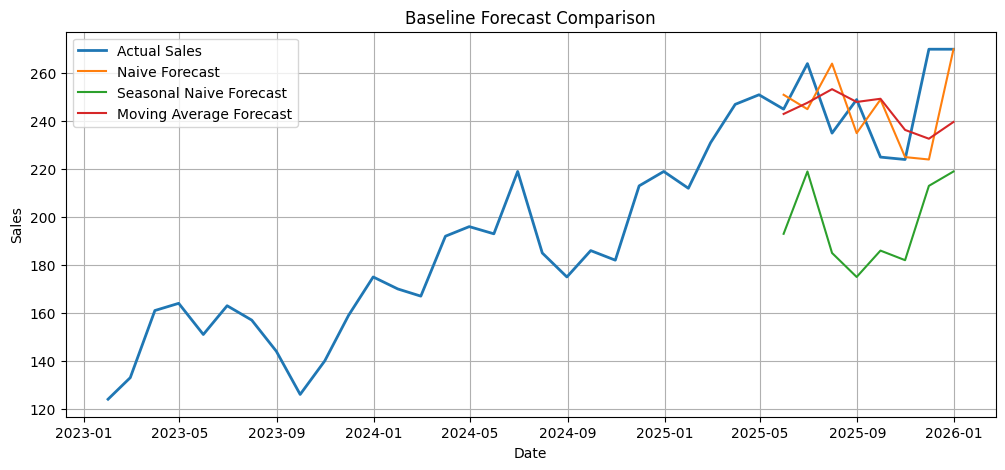

In [39]:
plt.figure(figsize=(12,5))

# Actual sales
plt.plot(
    df.index,
    df['Sales'],
    label='Actual Sales',
    linewidth=2
)

# Forecast models
plt.plot(
    test.index,
    test['Naive_Forecast'],
    label='Naive Forecast'
)

plt.plot(
    test.index,
    test['Seasonal_Naive'],
    label='Seasonal Naive Forecast'
)

plt.plot(
    test.index,
    test['Moving_Avg_Forecast'],
    label='Moving Average Forecast'
)

plt.title("Baseline Forecast Comparison")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()


# 7. Forecast Evaluation Metrics

Forecasting models are evaluated by comparing predictions against actual values.

We use:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- MAPE (Mean Absolute Percentage Error)


In [40]:

evaluation_df = test.dropna()

models = {
    'Naive': evaluation_df['Naive_Forecast'],
    'Seasonal Naive': evaluation_df['Seasonal_Naive'],
    'Moving Average': evaluation_df['Moving_Avg_Forecast']
}

results = []

for name, predictions in models.items():

    mae = mean_absolute_error(
        evaluation_df['Sales'],
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            evaluation_df['Sales'],
            predictions
        )
    )

    mape = np.mean(
        np.abs(
            (evaluation_df['Sales'] - predictions)
            / evaluation_df['Sales']
        )
    ) * 100

    results.append([
        name,
        round(mae,2),
        round(rmse,2),
        round(mape,2)
    ])

results_df = pd.DataFrame(
    results,
    columns=['Model','MAE','RMSE','MAPE']
)

results_df


,Model,MAE,RMSE,MAPE
0,Naive,17.38,22.71,6.97
1,Seasonal Naive,51.25,52.25,20.67
2,Moving Average,17.75,21.41,7.07



# 8. Final Interpretation

Several important forecasting insights emerge from the evaluation:

- The dataset is strongly trend-driven.
- Seasonal behavior exists but is not dominant.
- Random fluctuations introduce forecasting uncertainty.
- Simple naive forecasting struggles during periods of strong growth.
- Moving average forecasting smooths noise but reacts slowly to rapid changes.

This demonstrates why forecasting performance depends heavily on the structural characteristics of the underlying system.



# 9. Summary

In this notebook we:

- created a realistic retail forecasting dataset
- implemented baseline forecasting models
- visualized forecast behavior
- evaluated forecasting accuracy
- interpreted forecasting performance from a business perspective

These baseline systems establish the foundation for more advanced forecasting models such as ARIMA, Prophet, and deep learning approaches.
